# Imports

In [2]:
import pandas as pd
import re
import ftfy
from unidecode import unidecode
import spacy
from tqdm import tqdm

# Load CSV

In [3]:
df = pd.read_csv("mcu_imdb_reviews.csv")

# Combine summary + content and remove NAs
df["summary"] = df["summary"].fillna("").astype(str)
df["content"] = df["content"].fillna("").astype(str)
df["text"] = df["summary"] + " " + df["content"]
df_NER = df.copy()

# Basic Cleaning


In [4]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs, tho unlikey to have any
    text = ftfy.fix_text(text) # fix encoding issues
    text = unidecode(text) # convert to ASCII - removes encoding artifacts
    text = re.sub(r"[-()\[\]{}]", " ", text) # Replace with space, because in the reviews ppl often to have spacing before/after brackets
    
    return text

# Microtext Normalization

In [5]:
#Abbrievations are referenced from https://www.kaggle.com/code/nmaguette/up-to-date-list-of-slangs-for-text-preprocessing/notebook
abbreviations = {
    "$" : " dollar ",
    "€" : " euro ",
    "4ao" : "for adults only",
    "a.m" : "before midday",
    "a3" : "anytime anywhere anyplace",
    "aamof" : "as a matter of fact",
    "acct" : "account",
    "adih" : "another day in hell",
    "afaic" : "as far as i am concerned",
    "afaict" : "as far as i can tell",
    "afaik" : "as far as i know",
    "afair" : "as far as i remember",
    "afk" : "away from keyboard",
    "app" : "application",
    "approx" : "approximately",
    "apps" : "applications",
    "asap" : "as soon as possible",
    "asl" : "age, sex, location",
    "atk" : "at the keyboard",
    "ave." : "avenue",
    "aymm" : "are you my mother",
    "ayor" : "at your own risk", 
    "b&b" : "bed and breakfast",
    "b+b" : "bed and breakfast",
    "b.c" : "before christ",
    "b2b" : "business to business",
    "b2c" : "business to customer",
    "b4" : "before",
    "b4n" : "bye for now",
    "b@u" : "back at you",
    "bae" : "before anyone else",
    "bak" : "back at keyboard",
    "bbbg" : "bye bye be good",
    "bbc" : "british broadcasting corporation",
    "bbias" : "be back in a second",
    "bbl" : "be back later",
    "bbs" : "be back soon",
    "be4" : "before",
    "bfn" : "bye for now",
    "blvd" : "boulevard",
    "bout" : "about",
    "brb" : "be right back",
    "bros" : "brothers",
    "brt" : "be right there",
    "bsaaw" : "big smile and a wink",
    "btw" : "by the way",
    "bwl" : "bursting with laughter",
    "c/o" : "care of",
    "cet" : "central european time",
    "cf" : "compare",
    "cia" : "central intelligence agency",
    "csl" : "can not stop laughing",
    "cu" : "see you",
    "cul8r" : "see you later",
    "cv" : "curriculum vitae",
    "cwot" : "complete waste of time",
    "cya" : "see you",
    "cyt" : "see you tomorrow",
    "dae" : "does anyone else",
    "dbmib" : "do not bother me i am busy",
    "diy" : "do it yourself",
    "dm" : "direct message",
    "dwh" : "during work hours",
    "e123" : "easy as one two three",
    "eet" : "eastern european time",
    "eg" : "example",
    "embm" : "early morning business meeting",
    "encl" : "enclosed",
    "encl." : "enclosed",
    "etc" : "and so on",
    "faq" : "frequently asked questions",
    "fawc" : "for anyone who cares",
    "fb" : "facebook",
    "fc" : "fingers crossed",
    "fig" : "figure",
    "fimh" : "forever in my heart", 
    "ft." : "feet",
    "ft" : "featuring",
    "ftl" : "for the loss",
    "ftw" : "for the win",
    "fwiw" : "for what it is worth",
    "fyi" : "for your information",
    "g9" : "genius",
    "gahoy" : "get a hold of yourself",
    "gal" : "get a life",
    "gcse" : "general certificate of secondary education",
    "gfn" : "gone for now",
    "gg" : "good game",
    "gl" : "good luck",
    "glhf" : "good luck have fun",
    "gmt" : "greenwich mean time",
    "gmta" : "great minds think alike",
    "gn" : "good night",
    "g.o.a.t" : "greatest of all time",
    "goat" : "greatest of all time",
    "goi" : "get over it",
    "gps" : "global positioning system",
    "gr8" : "great",
    "gratz" : "congratulations",
    "gyal" : "girl",
    "h&c" : "hot and cold",
    "hp" : "horsepower",
    "hr" : "hour",
    "hrh" : "his royal highness",
    "ht" : "height",
    "ibrb" : "i will be right back",
    "ic" : "i see",
    "icq" : "i seek you",
    "icymi" : "in case you missed it",
    "idc" : "i do not care",
    "idgadf" : "i do not give a damn fuck",
    "idgaf" : "i do not give a fuck",
    "idk" : "i do not know",
    "ie" : "that is",
    "i.e" : "that is",
    "ifyp" : "i feel your pain",
    "IG" : "instagram",
    "iirc" : "if i remember correctly",
    "ilu" : "i love you",
    "ily" : "i love you",
    "imho" : "in my humble opinion",
    "imo" : "in my opinion",
    "imu" : "i miss you",
    "iow" : "in other words",
    "irl" : "in real life",
    "j4f" : "just for fun",
    "jic" : "just in case",
    "jk" : "just kidding",
    "jsyk" : "just so you know",
    "l8r" : "later",
    "lb" : "pound",
    "lbs" : "pounds",
    "ldr" : "long distance relationship",
    "lmao" : "laugh my ass off",
    "lmfao" : "laugh my fucking ass off",
    "lol" : "laughing out loud",
    "ltd" : "limited",
    "ltns" : "long time no see",
    "m8" : "mate",
    "mf" : "motherfucker",
    "mfs" : "motherfuckers",
    "mfw" : "my face when",
    "mofo" : "motherfucker",
    "mph" : "miles per hour",
    "mr" : "mister",
    "mrw" : "my reaction when",
    "ms" : "miss",
    "mte" : "my thoughts exactly",
    "nagi" : "not a good idea",
    "nbc" : "national broadcasting company",
    "nbd" : "not big deal",
    "nfs" : "not for sale",
    "ngl" : "not going to lie",
    "nhs" : "national health service",
    "nrn" : "no reply necessary",
    "nsfl" : "not safe for life",
    "nsfw" : "not safe for work",
    "nth" : "nice to have",
    "nvr" : "never",
    "nyc" : "new york city",
    "oc" : "original content",
    "og" : "original",
    "ohp" : "overhead projector",
    "oic" : "oh i see",
    "omdb" : "over my dead body",
    "omg" : "oh my god",
    "omw" : "on my way",
    "p.a" : "per annum",
    "p.m" : "after midday",
    "pm" : "prime minister",
    "poc" : "people of color",
    "pov" : "point of view",
    "pp" : "pages",
    "ppl" : "people",
    "prw" : "parents are watching",
    "ps" : "postscript",
    "pt" : "point",
    "ptb" : "please text back",
    "pto" : "please turn over",
    "qpsa" : "what happens", #"que pasa",
    "ratchet" : "rude",
    "rbtl" : "read between the lines",
    "rlrt" : "real life retweet", 
    "rofl" : "rolling on the floor laughing",
    "roflol" : "rolling on the floor laughing out loud",
    "rotflmao" : "rolling on the floor laughing my ass off",
    "rt" : "retweet",
    "ruok" : "are you ok",
    "sfw" : "safe for work",
    "sk8" : "skate",
    "smh" : "shake my head",
    "sq" : "square",
    "srsly" : "seriously", 
    "ssdd" : "same stuff different day",
    "tbh" : "to be honest",
    "tbs" : "tablespooful",
    "tbsp" : "tablespooful",
    "tfw" : "that feeling when",
    "thks" : "thank you",
    "tho" : "though",
    "thx" : "thank you",
    "tia" : "thanks in advance",
    "til" : "today i learned",
    "tl;dr" : "too long i did not read",
    "tldr" : "too long i did not read",
    "tmb" : "tweet me back",
    "tntl" : "trying not to laugh",
    "ttyl" : "talk to you later",
    "u" : "you",
    "u2" : "you too",
    "u4e" : "yours for ever",
    "utc" : "coordinated universal time",
    "w/" : "with",
    "w/o" : "without",
    "w8" : "wait",
    "wassup" : "what is up",
    "wb" : "welcome back",
    "wtf" : "what the fuck",
    "wtg" : "way to go",
    "wtpa" : "where the party at",
    "wuf" : "where are you from",
    "wuzup" : "what is up",
    "wywh" : "wish you were here",
    "yd" : "yard",
    "ygtr" : "you got that right",
    "ynk" : "you never know",
    "zzz" : "sleeping bored and tired"
}
# List of slangs I noticed in the dataset, so basically domain specific slangs
slang_dict = {
    "0/10": "very bad",
    "1/10": "very bad",
    "2/10": "bad",
    "3/10": "bad",
    "4/10": "normal",
    "5/10": "normal",
    "6/10": "normal",
    "7/10": "good",
    "8/10": "good",
    "9/10": "very good",
    "10/10": "very good",
    "cgi": "computer generated imagery",
    "sci": "science",
    "fi": "fiction",
    "rdj": "robert downey junior",
    "jr": "junior",
    "overrated": "bad",
    "cheesy": "poorly written",
    "predictable": "lacks originality",
    "cliche": "overused tropes",
    "cringe": "disgusting",
    "groundbreaking": "amazing",
    "wow": "amazing",
    "tv": "television",
    "mcu": "marvel cinematic universe"
}
merged = abbreviations | slang_dict
def normalize_slang(text):
    words = text.split()
    normalized = [merged.get(word, word) for word in words]
    return " ".join(normalized)

# Deeper Cleaning

In [6]:
#Removing is done here to prevent interference with Normalization
def deep_clean(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # remove punctuationa and special characters eg. / #
    return text


# Tokenization and Lemmatization

In [7]:
# Load English tokenizer, tagger, parser and NER
nlp = spacy.load("en_core_web_sm")
#Obtained from top 20 word count at bottom of notebook
custom_stopwords = {
    "movie", "film", "marvel", "character", "characters",
    "man", "story", "watch", "scene", "scenes",
    "universe", "avenger", "avengers", "s"
}

for word in custom_stopwords:
    nlp.Defaults.stop_words.add(word)
    nlp.vocab[word].is_stop = True

In [8]:
def tokenize_lemmatize(text):
    doc = nlp(text)
    tokens = []
    
    for token in doc:
        lemma = token.lemma_.lower()
        if lemma not in nlp.Defaults.stop_words and not token.is_punct:
            tokens.append(lemma)
    
    return tokens

# Pipeline

In [9]:
def preprocess(text):
    text = basic_clean(text)
    text = normalize_slang(text)
    text = deep_clean(text)
    tokens = tokenize_lemmatize(text)
    return " ".join(tokens)

# Applying onto dataset

In [25]:
df["processed_text"] = df["text"].apply(preprocess)

In [27]:
df["processed_text"]

0        well cinematic movie attempt rewatch cinematic...
1        superhero class come rank superhero live actio...
2        not waste life stark b list superhero risky le...
3        begin queue acdc cinematic 2021 marathon cinem...
4        robert downey junior iron tony stark robert do...
                               ...                        
90305    feel like passive aggressiv pro life love cons...
90306    fantastic step mark significant reintroduction...
90307    direct matt shakman focus spectacle emotional ...
90308    fantastic step mark important new beginning ma...
90309    good version ff hesitant base previous one ve ...
Name: processed_text, Length: 90310, dtype: str

# Exporting preprocessed text to csv

In [28]:
df.to_csv("preprocessed_data.csv", index=False)

# Analysing potential stop words

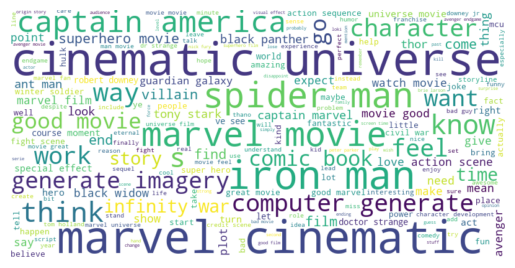

In [15]:
all_text = " ".join(df["processed_text"].dropna())
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [16]:
from collections import Counter

words = all_text.split()
word_counts = Counter(words)

# Top 20 most common words
print(word_counts.most_common(20))

[('movie', 248330), ('film', 124140), ('marvel', 115190), ('not', 114617), ('good', 98751), ('character', 84852), ('like', 81345), ('man', 58513), ('great', 52870), ('time', 51017), ('story', 48732), ('watch', 45670), ('action', 44475), ('feel', 43500), ('universe', 43426), ('scene', 43144), ('s', 38648), ('avenger', 34253), ('bad', 33955), ('think', 33674)]


# Adding NER to preprocess

# Initialise list of marvel movies

In [10]:
movie_map = {
    "tt0371746": "Iron Man",
    "tt0800080": "The Incredible Hulk",
    "tt1228705": "Iron Man 2",
    "tt0800369": "Thor",
    "tt0458339": "Captain America: The First Avenger",
    "tt0848228": "The Avengers",
    "tt1300854": "Iron Man 3",
    "tt1981115": "Thor: The Dark World",
    "tt1843866": "Captain America: The Winter Soldier",
    "tt2015381": "Guardians of the Galaxy",
    "tt2395427": "Avengers: Age of Ultron",
    "tt0478970": "Ant-Man",
    "tt3498820": "Captain America: Civil War",
    "tt1211837": "Doctor Strange",
    "tt3896198": "Guardians of the Galaxy Vol. 2",
    "tt2250912": "Spider-Man: Homecoming",
    "tt3501632": "Thor: Ragnarok",
    "tt1825683": "Black Panther",
    "tt4154756": "Avengers: Infinity War",
    "tt5095030": "Ant-Man and the Wasp",
    "tt4154796": "Avengers: Endgame",
    "tt6320628": "Spider-Man: Far From Home",
    "tt4154664": "Captain Marvel",
    "tt3480822": "Black Widow",
    "tt9376612": "Shang-Chi and the Legend of the Ten Rings",
    "tt9032400": "Eternals",
    "tt10872600": "Spider-Man: No Way Home",
    "tt9419884": "Doctor Strange in the Multiverse of Madness",
    "tt10648342": "Thor: Love and Thunder",
    "tt9114286": "Black Panther: Wakanda Forever",
    "tt10954600": "Ant-Man and the Wasp: Quantumania",
    "tt6791350": "Guardians of the Galaxy Vol. 3",
    "tt10676048": "The Marvels",
    "tt6263850": "Deadpool & Wolverine",
    "tt14513804": "Captain America: Brave New World",
    "tt20969586": "Thunderbolts*",
    "tt10676052": "The Fantastic Four: First Steps",
}

# Normalize function exclusively for movie titles

In [11]:
def normalize(text):
    return re.sub(r"[^a-z0-9\s]", "", text.lower())

# Include Aliases for better accuracy

In [12]:
# Base titles
movie_titles = {normalize(v): v for v in movie_map.values()}

# Aliases (IMPORTANT)
aliases = {
    "endgame": "Avengers: Endgame",
    "infinity war": "Avengers: Infinity War",
    "civil war": "Captain America: Civil War",
    "winter soldier": "Captain America: The Winter Soldier",
    "first avenger": "Captain America: The First Avenger",
    "dark world": "Thor: The Dark World",
    "ragnarok": "Thor: Ragnarok",
    "love and thunder": "Thor: Love and Thunder",
    "homecoming": "Spider-Man: Homecoming",
    "far from home": "Spider-Man: Far From Home",
    "no way home": "Spider-Man: No Way Home",
    "multiverse of madness": "Doctor Strange in the Multiverse of Madness",
    "wakanda forever": "Black Panther: Wakanda Forever",
    "quantumania": "Ant-Man and the Wasp: Quantumania",
    "vol 2": "Guardians of the Galaxy Vol. 2",
    "vol 3": "Guardians of the Galaxy Vol. 3",
}

# Merge aliases into lookup
for k, v in aliases.items():
    movie_titles[normalize(k)] = v

# To identify movies in the text

In [13]:
def find_movies_list(text):
    text_norm = normalize(text)
    found = set()
    
    for norm_title, original in movie_titles.items():
        if norm_title in text_norm:
            found.add(original)
    
    return found

# To remove sentances that are talking about other movies only

In [14]:
def filter_irrelevant_sentences_hybrid(doc, target_movie):
    target_norm = normalize(target_movie)
    relevant = []
    
    for sent in doc.sents:
        # Using both Rule base matching with movie list and NER to identify movies in the sentance
        list_movies = find_movies_list(sent.text)
        ner_movies = {
            ent.text for ent in sent.ents
            if ent.label_ == "WORK_OF_ART"
        }
        
        found_movies = list_movies.union(ner_movies)
        found_norm = {normalize(m) for m in found_movies}
        
        # Keep sentance if no movies in it or target movie is in it
        if not found_movies or target_norm in found_norm:
            relevant.append(sent.text)
    
    return " ".join(relevant)

# Pipeline to do sentance filtering using NER and rule based matching, along with the other preprocess from before

In [17]:
texts = df_NER["text"].tolist()
movies = df_NER["movie_title"].tolist()

# First pass: get docs WITH NER (needed for filtering)
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")
docs = list(nlp.pipe(texts, batch_size=50, disable=["parser"]))
print("Initial processing done")

# Step 1: Filter + clean (NO NLP here)
cleaned_texts = []

for doc, movie_title in tqdm(zip(docs, movies), total=len(docs)):
    # Filter sentences
    text = filter_irrelevant_sentences_hybrid(doc, movie_title)

    # Cleaning of data, done after to prevent interference with sentences identification
    text = basic_clean(text)
    text = normalize_slang(text)
    text = deep_clean(text)
    
    cleaned_texts.append(text)

print("Filtering and cleaning done")

# Second pass: ONLY run tagger for lemmatization (FAST)
processed_texts = []

for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=50, disable=["parser", "ner"])):
    
    tokens = [
        token.lemma_.lower()
        for token in doc
        if token.lemma_.lower() not in nlp.Defaults.stop_words and not token.is_punct
    ]
    
    processed_texts.append(" ".join(tokens))

print("Lemmatization done")

Initial processing done


100%|███████████████████████████████████████████████████████████████████████████| 90310/90310 [03:43<00:00, 403.40it/s]


Filtering and cleaning done


90310it [45:50, 32.83it/s]

Lemmatization done


In [18]:
df_NER["processed_text"] = processed_texts

In [19]:
df_NER["processed_text"]

0        cinematic attempt rewatch cinematic chronologi...
1        superhero class come rank superhero live actio...
2        waste life stark b list superhero risky lead a...
3        begin queue acdc cinematic 2021 marathon cinem...
4        robert downey junior iron tony stark robert do...
                               ...                        
90305    feel like passive aggressiv pro life love cons...
90306    fantastic step mark significant reintroduction...
90307    direct matt shakman focus spectacle emotional ...
90308    fantastic step mark important new beginning fa...
90309    good version ff hesitant base previous ve 4 ti...
Name: processed_text, Length: 90310, dtype: str

In [20]:
df_NER

,movie_id,movie_title,review_id,author,author_rating,upvotes,downvotes,submission_date,summary,content,text,processed_text
0,tt0371746,Iron Man,rw4383391,bjoernidler,8.0,284,16,2018-10-07,Still one of the best MCU-movies,In my attempt to rewatch all the MCU-movies ch...,Still one of the best MCU-movies In my attempt...,cinematic attempt rewatch cinematic chronologi...
1,tt0371746,Iron Man,rw3067309,TheLittleSongbird,9.0,105,5,2014-08-12,A Marvel superhero film done with class,When it comes to ranking the Marvel superhero(...,A Marvel superhero film done with class When i...,superhero class come rank superhero live actio...
2,tt0371746,Iron Man,rw3765080,jhudson-11704,9.0,113,9,2017-07-27,"Don't waste your life, Stark","With a B-list superhero, a risky lead actor, a...","Don't waste your life, Stark With a B-list sup...",waste life stark b list superhero risky lead a...
3,tt0371746,Iron Man,rw6571911,repojack,8.0,57,3,2021-02-07,This is where it all began. Queue AC/DC.,MCU 2021 Marathon MCU #1: Iron Man was my fa...,This is where it all began. Queue AC/DC. MCU 2...,begin queue acdc cinematic 2021 marathon cinem...
4,tt0371746,Iron Man,rw2918335,SnoopyStyle,8.0,35,3,2013-12-07,RDJ is Iron Man,Tony Stark (Robert Downey Jr.) is a hard playi...,RDJ is Iron Man Tony Stark (Robert Downey Jr.)...,robert downey junior iron tony stark robert do...
...,...,...,...,...,...,...,...,...,...,...,...,...
90305,tt10676052,The Fantastic Four: First Steps,rw11285078,agnesliversedge,2.0,0,0,2026-03-04,feels like passive aggressiv pro life.,I love the consept of a superhero that gets pr...,feels like passive aggressiv pro life. I love ...,feel like passive aggressiv pro life love cons...
90306,tt10676052,The Fantastic Four: First Steps,rw11242873,yatopa,NaN,0,0,2026-02-21,The Fantastic Four: First Steps marks a signif...,"The story centers on Reed Richards, Sue Storm,...",The Fantastic Four: First Steps marks a signif...,fantastic step mark significant reintroduction...
90307,tt10676052,The Fantastic Four: First Steps,rw11256087,vapoy-5,NaN,0,0,2026-02-23,"Directed by Matt Shakman, the film focuses les...","The story centers on Reed Richards, Sue Storm,...","Directed by Matt Shakman, the film focuses les...",direct matt shakman focus spectacle emotional ...
90308,tt10676052,The Fantastic Four: First Steps,rw11240907,jepotol,NaN,0,0,2026-02-21,The Fantastic Four: First Steps marks an impor...,"The story centers on Reed Richards, Sue Storm,...",The Fantastic Four: First Steps marks an impor...,fantastic step mark important new beginning fa...


# Exporting NER preprocessed text to csv

In [21]:
df_NER.to_csv("NER_preprocessed_data.csv", index=False)